In [2]:
# 📦 1. Import Library & Load Data
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

df = pd.read_csv("clean_jobs.csv")
df.drop(columns=["work_type", "employment_type"], inplace=True)


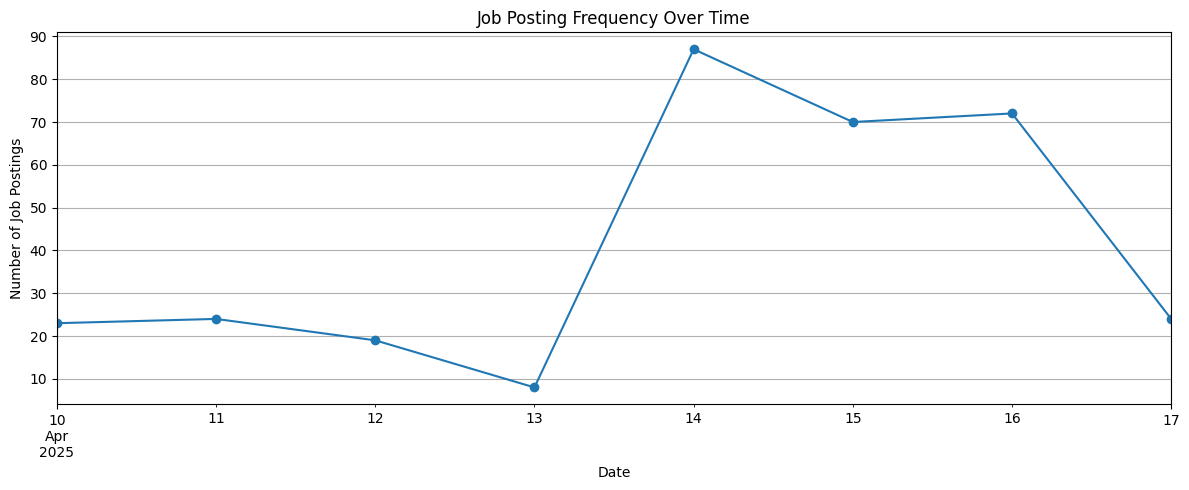

In [3]:
# 📅 2. Job Posting Trends Over Time
df['date_posted'] = pd.to_datetime(df['date_posted'])
postings_per_day = df['date_posted'].value_counts().sort_index()

plt.figure(figsize=(12,5))
postings_per_day.plot(marker='o')
plt.title("Job Posting Frequency Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Job Postings")
plt.grid(True)
plt.tight_layout()
plt.show()


Caption: Grafik ini menunjukkan jumlah postingan pekerjaan dari hari ke hari. Cocok untuk mengamati puncak rekrutmen.

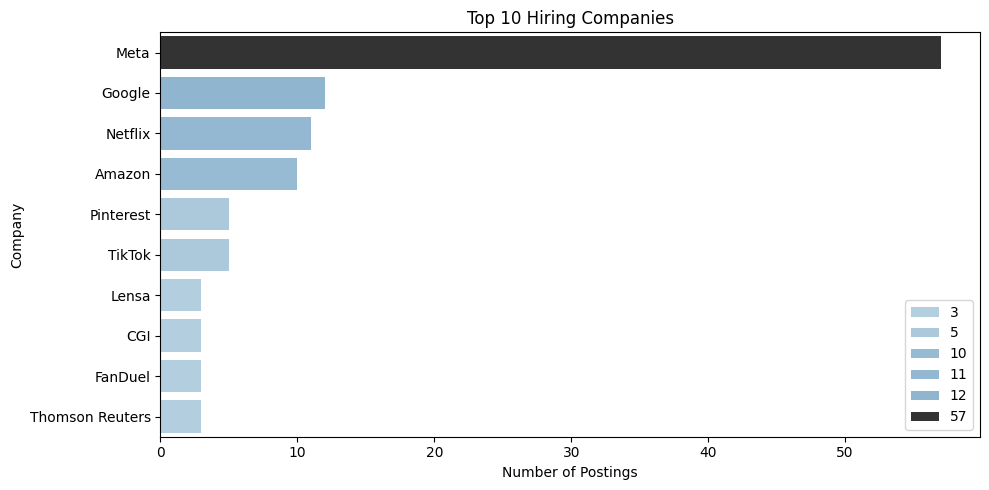

In [5]:
# 🏢 3. Top Hiring Companies
top_companies = df['company'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_companies.values, hue=top_companies.values, y=top_companies.index, palette="Blues_d")
plt.title("Top 10 Hiring Companies")
plt.xlabel("Number of Postings")
plt.ylabel("Company")
plt.tight_layout()
plt.show()


Caption: Perusahaan yang paling aktif merekrut berdasarkan jumlah lowongan yang diposting.

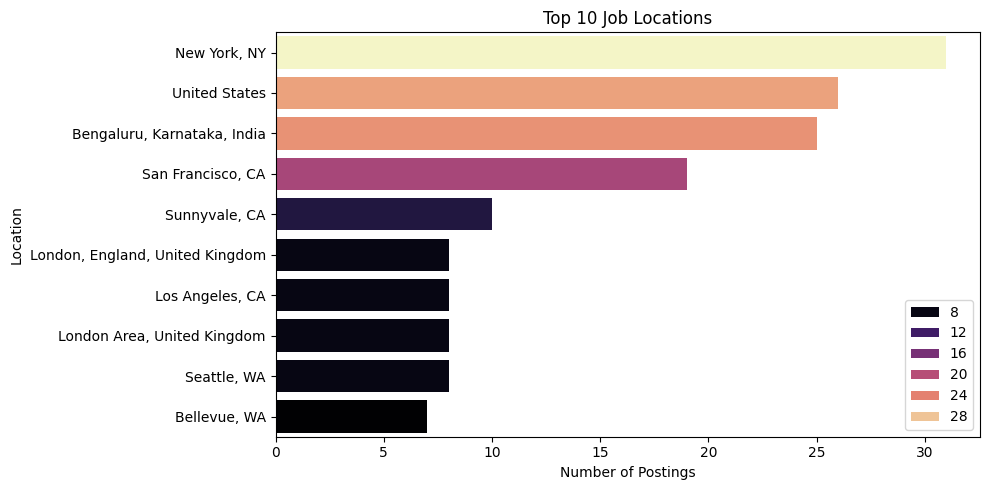

In [6]:
# 📍 4. Geographic Distribution of Jobs
top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_locations.values, hue=top_locations.values, y=top_locations.index, palette="magma")
plt.title("Top 10 Job Locations")
plt.xlabel("Number of Postings")
plt.ylabel("Location")
plt.tight_layout()
plt.show()


Caption: Lokasi yang paling banyak menawarkan pekerjaan untuk posisi data analyst.

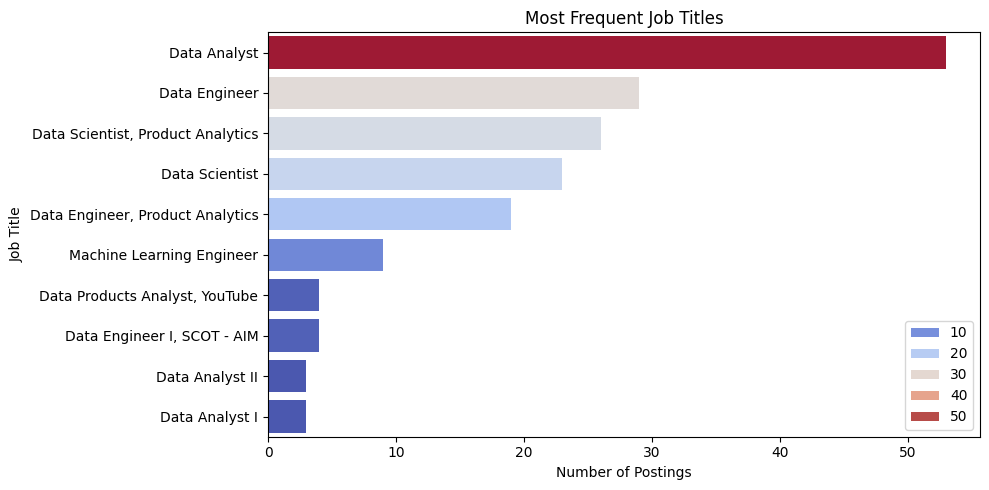

In [8]:
# 🔎 5. Common Job Titles
top_titles = df['title'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_titles.values, hue=top_titles.values, y=top_titles.index, palette="coolwarm")
plt.title("Most Frequent Job Titles")
plt.xlabel("Number of Postings")
plt.ylabel("Job Title")
plt.tight_layout()
plt.show()


Caption: Judul pekerjaan yang paling umum di bidang data dalam dataset ini.

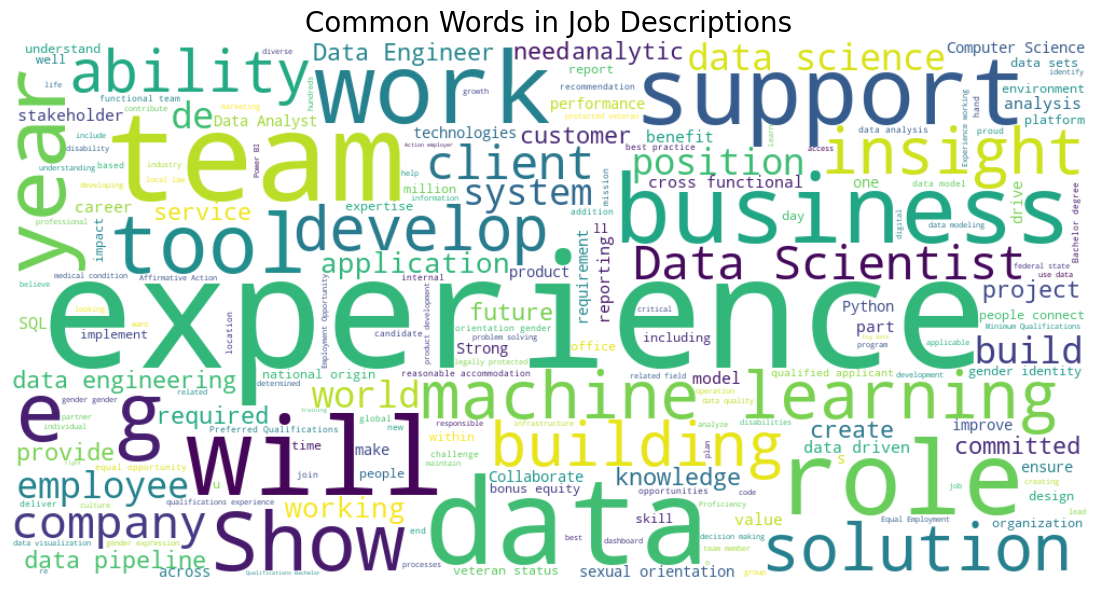

In [9]:
# 📑 6. Word Cloud of Job Descriptions
all_text = ' '.join(df['description'].dropna().tolist())
wordcloud = WordCloud(width=1000, height=500, background_color='white').generate(all_text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("Common Words in Job Descriptions", fontsize=20)
plt.show()


Caption: Visualisasi kata paling sering digunakan dalam deskripsi pekerjaan.

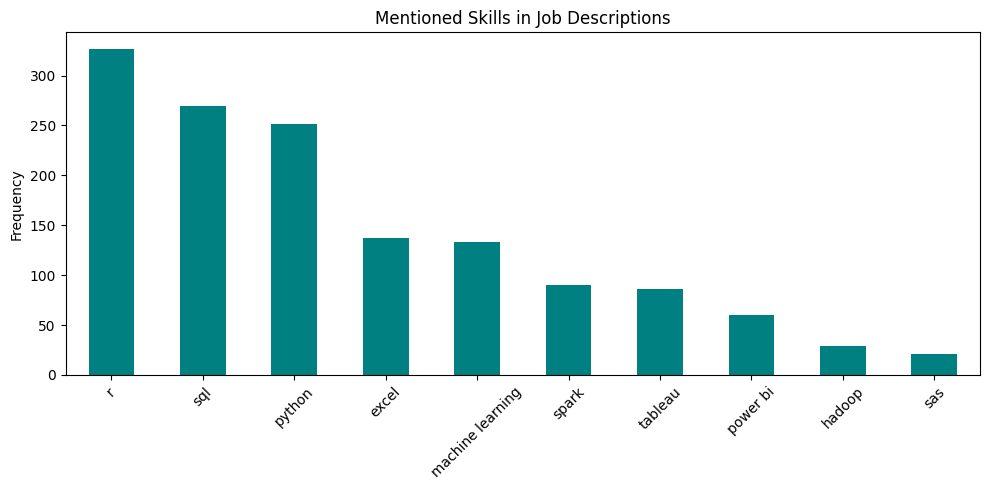

In [10]:
# 🧠 7. Skill Extraction
skills = ['sql', 'python', 'excel', 'tableau', 'power bi', 'r', 'sas', 'spark', 'hadoop', 'machine learning']
df['skills_mentioned'] = df['description'].apply(lambda x: [s for s in skills if s in x.lower()])

skill_counts = pd.Series([s for sublist in df['skills_mentioned'] for s in sublist]).value_counts()

plt.figure(figsize=(10,5))
skill_counts.plot(kind='bar', color='teal')
plt.title("Mentioned Skills in Job Descriptions")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


Caption: Frekuensi penyebutan keterampilan teknis utama dalam deskripsi lowongan.

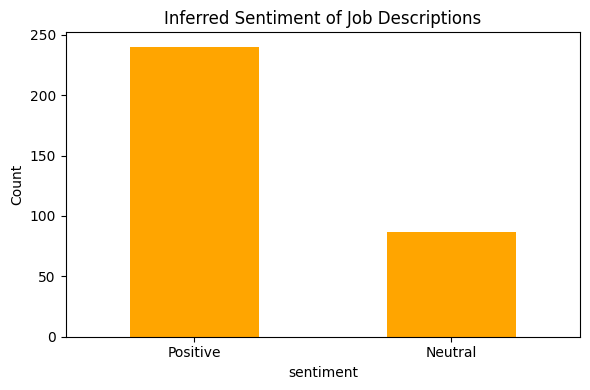

In [ ]:
# 📊 8. Sentiment (Descriptive Tone) Analysis – using keyword heuristics
def get_sentiment(text):
    text = text.lower()
    if "exciting" in text or "opportunity" in text or "growth" in text:
        return "Positive"
    elif "challenging" in text or "fast-paced" in text:
        return "Neutral"
    else:
        return "Neutral"

df['sentiment'] = df['description'].apply(get_sentiment)

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(6,4))
sentiment_counts.plot(kind='bar', color='orange')
plt.title("Inferred Sentiment of Job Descriptions")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Caption: Analisis sentimen berdasarkan kata kunci untuk mengetahui nada umum dalam deskripsi pekerjaan.